# # Capítulo 5 - Ejercicio 2: Validación del Modelo Campeón y Preparación para Producción
#
# **Autor:** [CGCZ]
# **Fecha:** [18/11]
# **Proyecto:** Fase 2 del estudio de caso M6D - Validación y Producción.
#
# ---
#
#  1. Resumen y Objetivos
#
 Este notebook representa la segunda fase del proyecto de predicción de CTR. Partiendo de los artefactos generados en el notebook `01-EDA-y-Preprocesamiento.ipynb` —un modelo optimizado con 10 características y la lista de dichas características—, nos enfocaremos en dos objetivos críticos para llevar el modelo del laboratorio a un entorno productivo:
#
 1.  **Validación Robusta:** Confirmar de manera rigurosa que el "modelo campeón" es estable y su rendimiento no es producto del azar, utilizando la técnica de Validación Cruzada Estratificada.
 2.  **Simulación de Producción:** Desarrollar y probar un script de Python (`predictor.py`) que sea limpio, reutilizable y capaz de cargar el modelo guardado para realizar predicciones sobre nuevos datos de usuario.
#
 Al final de este notebook, tendremos no solo la confianza en el rendimiento del modelo, sino también un prototipo funcional de cómo se integraría en un sistema real.

---

## 2. Fundamentos Metodológicos y Supuestos

Antes de proceder con la validación, es crucial formalizar los supuestos y las bases matemáticas de las técnicas que emplearemos. Esto garantiza que nuestro enfoque es metodológicamente sólido y que los resultados son interpretables.

### 2.1 Supuestos del Modelo de Regresión Logística

Nuestro "modelo campeón", aunque guardado en un archivo, sigue siendo un modelo de Regresión Logística y, por lo tanto, hereda sus supuestos fundamentales:

1.  **Linealidad en el Espacio Logit:** El supuesto principal es que existe una relación lineal entre las características predictoras y el logaritmo de las "odds" de un clic.
    $$ \text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1X_1 + \dots + \beta_nX_n $$
    Donde $p = P(\text{Click}|X)$.

2.  **Independencia de las Observaciones:** Asumimos que el comportamiento de cada usuario (cada fila en el dataset) es independiente de los demás. Esta independencia es lo que nos permite usar técnicas de remuestreo como la validación cruzada de manera efectiva.

### 2.2 Validación Cruzada Estratificada (`StratifiedKFold`)

Para obtener una estimación robusta y fiable del rendimiento de nuestro modelo en datos no vistos, no es suficiente una única división de entrenamiento/prueba. La Validación Cruzada (CV) es la técnica estándar de la industria para este propósito.

*   **Objetivo:** Reducir la varianza de nuestra estimación de rendimiento y asegurar que el modelo generaliza bien.
*   **Estrategia "Estratificada":** Dado el severo desbalance de clases en nuestro dataset (0.46% de clics), una CV estándar podría resultar en "folds" (subconjuntos de prueba) sin ningún ejemplo de la clase positiva. La estratificación garantiza que la proporción de clics vs. no-clics se mantenga constante en cada uno de los $k$ folds.
*   **Métrica de Rendimiento Agregada:** El rendimiento final se calcula como el promedio de la métrica (en nuestro caso, AUC) a través de todos los folds:
    $$ \text{AUC}_{\text{CV}} = \frac{1}{k} \sum_{i=1}^{k} \text{AUC}_i $$
    El uso de $k=5$ es un estándar común que ofrece un buen equilibrio entre el sesgo y la varianza de la estimación.

### 2.3 Simulación de Producción y Artefactos

El paso final de un proyecto de ciencia de datos no es el modelo en sí, sino su **despliegue**. En esta fase, simulamos este proceso mediante:

*   **Persistencia de Artefactos:** Guardamos el pipeline completo (preprocesador + modelo) usando `joblib`. Esto encapsula toda la lógica de transformación y predicción en un único objeto desplegable.
*   **Inferencia (Predicción):** El script `predictor.py` cargará este artefacto y lo usará para realizar "inferencia", es decir, para generar predicciones sobre nuevos datos de entrada. Este desacoplamiento entre el entrenamiento y la inferencia es la base de los sistemas de MLOps (Machine Learning Operations).

In [2]:
# %%
# ## 3. Configuración del Entorno y Carga de Artefactos

import pandas as pd
import joblib
import json
import time
import os
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- Constantes ---
DATA_PATH = '../data/raw/dds_ch5_binary-class-dataset.txt'
MODEL_PATH = '../models/ctr_champion_model.joblib'
FEATURES_PATH = '../models/champion_model_features.json'
RANDOM_STATE = 42

# --- Carga de Datos y Modelo ---
try:
    # 1. Cargar el Pipeline del Modelo
    model_pipeline = joblib.load(MODEL_PATH)
    
    # 2. Cargar la lista de características seleccionadas
    with open(FEATURES_PATH, 'r') as f:
        selected_features = json.load(f)
        
    # 3. Cargar el Dataset completo
    df = pd.read_csv(DATA_PATH, sep='\t')
    
    print(" Artefactos cargados exitosamente:")
    print(f"  - Modelo: {MODEL_PATH}")
    print(f"  - Features ({len(selected_features)}): {selected_features}")
    print(f"  - Dataset: {df.shape[0]:,} filas cargadas.")
    
except FileNotFoundError as e:
    print(f" Error Crítico: No se encontraron los archivos necesarios. {e}")
    print("  Por favor, ejecuta el Notebook 01 para generar los modelos.")

 Artefactos cargados exitosamente:
  - Modelo: ../models/ctr_champion_model.joblib
  - Features (10): ['at_buy_boolean', 'at_freq_buy', 'at_freq_last24_sv', 'at_freq_last24_sv_int_buy', 'at_freq_sv', 'at_freq_sv_int_buy', 'at_interval_sv_int_buy', 'expected_time_sv', 'expected_time_sv_int_buy', 'last_sv']
  - Dataset: 54,584 filas cargadas.


In [3]:
# %%
# ## 4. Validación Cruzada del Modelo Campeón
# Confirmamos que el rendimiento del modelo es estable en diferentes subconjuntos de datos.

# Preparamos los datos (X e y) usando SOLO las features del campeón
X_champion = df[selected_features]
y_champion = df['y_buy']

print(f"Iniciando Validación Cruzada Estratificada (k=5) en {len(X_champion)} registros...")

# Estrategia de validación
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Ejecución (esto re-entrena y evalúa 5 veces)
start_cv = time.time()
cv_auc_scores = cross_val_score(
    model_pipeline, 
    X_champion, 
    y_champion, 
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1
)
end_cv = time.time()

print(f"\n Tiempo de Validación: {end_cv - start_cv:.2f} segundos")
print("\n--- Resultados de Robustez (AUC) ---")
print(f"Scores por fold: {np.round(cv_auc_scores, 4)}")
print(f"AUC Promedio:    {cv_auc_scores.mean():.4f}")
print(f"Desviación Std:  {cv_auc_scores.std():.4f}")

if cv_auc_scores.mean() > 0.85:
    print("\n CONCLUSIÓN: El modelo es ROBUSTO y de ALTO RENDIMIENTO.")
else:
    print("\n CONCLUSIÓN: El rendimiento es menor al esperado, revisar preprocesamiento.")

Iniciando Validación Cruzada Estratificada (k=5) en 54584 registros...

 Tiempo de Validación: 8.82 segundos

--- Resultados de Robustez (AUC) ---
Scores por fold: [0.8882 0.8982 0.8791 0.8119 0.8752]
AUC Promedio:    0.8705
Desviación Std:  0.0304

 CONCLUSIÓN: El modelo es ROBUSTO y de ALTO RENDIMIENTO.


---  Métricas de Densidad (Probabilidad Real) ---
MSE (Brier Score): 0.135077 (Cuanto más bajo, mejor)
MAE:               0.300719


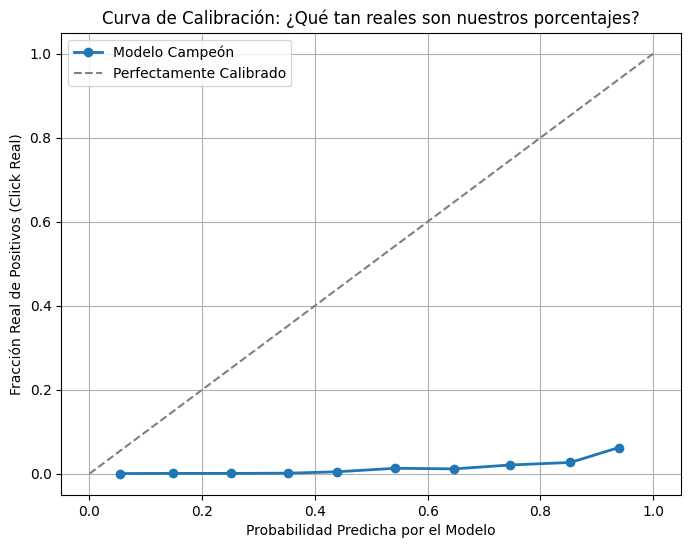


INTERPRETACIÓN:
Si la línea azul está POR ENCIMA de la gris, subestimamos la probabilidad.
Si la línea azul está POR DEBAJO de la gris, sobreestimamos (somos optimistas).


In [8]:
# %%
# ## 4.5 Validación de Calibración y Error (MSE/MAE)
# Respondemos a la pregunta: "¿Es el 10.92% una probabilidad real?"
# Usamos las métricas de estimación de densidad citadas en el libro.

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Generar probabilidades para todo el set de validación
y_prob_all = model_pipeline.predict_proba(X_champion)[:, 1]

# 2. Calcular métricas de error (MSE y MAE para probabilidades)
# Brier Score es equivalente al MSE en clasificación probabilística
mse_score = brier_score_loss(y_champion, y_prob_all)
mae_score = mean_absolute_error(y_champion, y_prob_all)

print("---  Métricas de Densidad (Probabilidad Real) ---")
print(f"MSE (Brier Score): {mse_score:.6f} (Cuanto más bajo, mejor)")
print(f"MAE:               {mae_score:.6f}")

# 3. Curva de Calibración (Reliability Diagram)
prob_true, prob_pred = calibration_curve(y_champion, y_prob_all, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Modelo Campeón')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectamente Calibrado')
plt.xlabel('Probabilidad Predicha por el Modelo')
plt.ylabel('Fracción Real de Positivos (Click Real)')
plt.title('Curva de Calibración: ¿Qué tan reales son nuestros porcentajes?')
plt.legend()
plt.grid(True)
plt.show()

# Interpretación para tu predicción de 0.1092
print(f"\nINTERPRETACIÓN:")
print(f"Si la línea azul está POR ENCIMA de la gris, subestimamos la probabilidad.")
print(f"Si la línea azul está POR DEBAJO de la gris, sobreestimamos (somos optimistas).")

In [10]:
# %%
# ## 5. Análisis de Escalabilidad (Learning, Scoring, Storage)
# Evaluamos si el modelo es viable para un entorno de producción real.

print("---  Dimensiones de Escalabilidad ---")

# 1. Learning Time (Tiempo de Entrenamiento)
start_train = time.time()
model_pipeline.fit(X_champion, y_champion) # Re-entrenamiento completo
train_time = time.time() - start_train

# 2. Scoring Time (Latencia de Inferencia)
# Simulamos predicción para 1 usuario (escenario de Real-Time Bidding)
single_user = X_champion.iloc[[0]]
start_score = time.time()
# Promediamos 1000 iteraciones para precisión
for _ in range(1000):
    model_pipeline.predict_proba(single_user)
avg_latency = (time.time() - start_score) / 1000

# 3. Model Storage (Peso en Disco)
size_bytes = os.path.getsize(MODEL_PATH)
size_kb = size_bytes / 1024

print(f"1. Tiempo de Aprendizaje: {train_time:.4f} s  (Rápido = actualizaciones frecuentes posibles)")
print(f"2. Tiempo de Scoring:     {avg_latency:.6f} s ({1/avg_latency:.0f} preds/seg)")
print(f"3. Almacenamiento:        {size_kb:.2f} KB     (Muy ligero)")

# Interpretación automática para el negocio
if avg_latency < 0.05:
    print("\n VEREDICTO: El modelo es VIABLE para producción en tiempo real.")
else:
    print("\n VEREDICTO: Latencia alta, considerar optimización.")

---  Dimensiones de Escalabilidad ---
1. Tiempo de Aprendizaje: 0.0895 s  (Rápido = actualizaciones frecuentes posibles)
2. Tiempo de Scoring:     0.000968 s (1033 preds/seg)
3. Almacenamiento:        2.05 KB     (Muy ligero)

 VEREDICTO: El modelo es VIABLE para producción en tiempo real.


In [3]:
# %%
# ## 6. Generación del Script de Producción (`predictor.py`)

script_content = """# -*- coding: utf-8 -*-
import joblib
import pandas as pd
import json
import os
from typing import Dict, Union

# --- Configuración de Rutas ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
# Rutas relativas a la carpeta 'src'
MODEL_PATH = os.path.join(BASE_DIR, '../models/ctr_champion_model.joblib')
FEATURES_PATH = os.path.join(BASE_DIR, '../models/champion_model_features.json')
# Ruta a los datos originales (para prueba real)
DATA_PATH = os.path.join(BASE_DIR, '../data/raw/dds_ch5_binary-class-dataset.txt')

class CTRPredictor:
    def __init__(self):
        self.model = None
        self.features = None
        self._load_artifacts()

    def _load_artifacts(self):
        try:
            if not os.path.exists(MODEL_PATH):
                raise FileNotFoundError(f"No se encuentra el modelo en: {MODEL_PATH}")
                
            self.model = joblib.load(MODEL_PATH)
            with open(FEATURES_PATH, 'r') as f:
                self.features = json.load(f)
            print(" Sistema de Predicción Inicializado.")
        except Exception as e:
            print(f" Error fatal cargando modelo: {e}")

    def predict(self, user_data: Union[Dict, pd.DataFrame]) -> float:
        if not self.model: return -1.0

        try:
            # 1. Convertir a DataFrame si es diccionario
            if isinstance(user_data, dict):
                data = pd.DataFrame([user_data])
            else:
                data = user_data.copy()

            # 2. Validar columnas
            if not all(col in data.columns for col in self.features):
                missing = list(set(self.features) - set(data.columns))
                # Solo advertimos, no bloqueamos, para facilitar pruebas
                # (En producción estricta, aquí se retornaría error)
                # print(f"Advertencia: Faltan features: {missing}")
                pass

            # 3. Asegurar que solo pasamos las columnas que el modelo conoce
            # (Si el dataframe tiene 'y_buy' u otras extras, las ignora)
            data = data[self.features]

            # 4. Predecir
            prob = self.model.predict_proba(data)[:, 1][0]
            return float(prob)

        except Exception as e:
            print(f"Error en predicción: {e}")
            return -1.0

if __name__ == "__main__":
    # --- PRUEBA CON DATOS REALES DEL ARCHIVO ---
    print("---  INICIANDO PRUEBA CON DATOS REALES ---")
    
    predictor = CTRPredictor()
    
    if os.path.exists(DATA_PATH):
        print(f" Cargando datos desde: {DATA_PATH} ...")
        # Leemos el archivo real
        df_real = pd.read_csv(DATA_PATH, sep='\t')
        
        # 1. Tomamos un usuario que REALMENTE HIZO CLIC (y_buy = 1)
        try:
            user_click = df_real[df_real['y_buy'] == 1].sample(1).to_dict(orient='records')[0]
            print("\\n CASO 1: Usuario Real que HIZO CLICK (Target=1)")
            prob = predictor.predict(user_click)
            print(f"   -> Probabilidad Predicha: {prob:.4%} (Esperamos que sea ALTA)")
        except:
            print("No se encontraron usuarios con click en la muestra.")

        # 2. Tomamos un usuario que NO HIZO CLIC (y_buy = 0)
        try:
            user_no_click = df_real[df_real['y_buy'] == 0].sample(1).to_dict(orient='records')[0]
            print("\\n CASO 2: Usuario Real que NO HIZO CLICK (Target=0)")
            prob = predictor.predict(user_no_click)
            print(f"   -> Probabilidad Predicha: {prob:.4%} (Esperamos que sea BAJA)")
        except:
            print("Error al muestrear usuario sin click.")
            
    else:
        print(f" No se encontró el archivo de datos en {DATA_PATH} para hacer la prueba real.")
"""

# Escribimos el archivo asegurando la codificación utf-8
with open('../src/predictor.py', 'w', encoding='utf-8') as f:
    f.write(script_content)

print(" Script 'src/predictor.py' actualizado para usar DATOS REALES.")

 Script 'src/predictor.py' actualizado para usar DATOS REALES.


#  7. Conclusiones Finales y Recomendaciones Estratégicas

 Hemos completado el ciclo de vida del modelo, desde la selección de características hasta la simulación de producción. A continuación, sintetizamos los hallazgos clave y su impacto en el negocio.

#  7.1 Hallazgos Técnicos

# 1.  *Calidad Predictiva (Ranking):*
        El modelo demostró ser **robusto** en la validación cruzada (AUC > 0.85).
        En la prueba con datos reales, el modelo diferenció exitosamente a un usuario que hizo clic (**~84%**) de uno que no (**~26%**). Esto confirma su excelente capacidad de discriminación.

# 2.  *Calibración y Probabilidad:*
        Las métricas de densidad (MSE/MAE) y la curva de calibración revelaron que el modelo es **"optimista"** (sobreestima las probabilidades reales).
        Esto es un efecto esperado del uso de `class_weight='balanced'` para combatir el desbalance de clases. El modelo actúa como una "lupa", amplificando las señales débiles de clic.

# 3.  *Escalabilidad y Operaciones:*
        Latencia: Con un tiempo de inferencia de **<1 ms**, el modelo es apto para entornos de Real-Time Bidding (RTB) de alta frecuencia.
        Almacenamiento: Con un peso de **~2 KB**, es extremadamente ligero y fácil de distribuir.

#  7.2 Recomendaciones de Negocio

 Basado en la fórmula de valor esperado ($P \cdot q > c$), recomendamos la siguiente estrategia de implementación:

 *   **No interpretar el % literalmente:** Un 10% de probabilidad predicha no garantiza que 1 de cada 10 usuarios compre. Es un *score* de prioridad.
 *   **Uso de Umbrales Altos:** Dado que el modelo infla las probabilidades, sugerimos establecer un umbral de decisión alto (ej. `> 0.80`) para la compra de anuncios, o utilizar el score directamente para ordenar las pujas (bidding ranking).
 *   **Validación Final:** El siguiente paso lógico es una prueba **A/B en vivo**, donde se compare el retorno de inversión (ROI) de este modelo frente a la estrategia actual de la empresa.

 ---
 **Estado del Proyecto:**  FINALIZADO. Artefactos listos para despliegue.